In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP


from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold,  StratifiedShuffleSplit

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm



config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CLeft'], ['CRight']]
config.session_type = 'S2'


config.test_session = 2


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0
config.stride = 0.25



config.n_csp_components = 3

# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']


model = NetCNN2D_CSP(len(config.used_classes))
model.build((32, 3, 750, 1))
model.summary()

model = NetCNN1D(len(config.used_classes))
model.build((32, 750, 3))
model.summary()





Model: "net_cnn2d_csp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 3, 108, 16)          608       
                                                                 
 sequential_1 (Sequential)   (32, 3, 22, 32)           10912     
                                                                 
 sequential_2 (Sequential)   (32, 32)                  0         
                                                                 
 fc (Sequential)             (32, 2)                   4482      
                                                                 
Total params: 16002 (62.51 KB)
Trainable params: 15906 (62.13 KB)
Non-trainable params: 96 (384.00 Byte)
_________________________________________________________________
Model: "net_cnn1d"
_________________________________________________________________
 Layer (type)                Output Shape              Pa

In [2]:
config.used_classes = [['CLeft'], ['CRight']]#, ['CUp'], ['CDown']]
config.session_type = 'S2'

X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)

print(X.shape)
print(y.shape)

(316, 13, 750)
(316,)


0it [00:00, ?it/s]

Training indices:  [ 26 130 281 276 209 123 278  43 149 308 260  28 253 229 213 216  13  46
 174 133  38 203 128  85  53 116 166 110 182  81 139 108 142 243 187 311
  74 263  39 154 199 104 181 122  48  72 192 290  99 302 218  36 125   6
 200  95  96 118   3   2 245 248 120 271 265  68 269  57 282 103 164 236
 168 221  64  92 132 246 270 121 266  32  56 131 191  79 301 146 299 268
  20 144   1 285 189 255  80  61 267   8 143  12  93 274  17 188 211 177
  84 252  44 183  71 117 101 254  34  98   5 310 173 202 156 223  62 247
 286 114 204 113 275 296  55 238 111 272 165  63  54 107   7 224  11  82
 256  87 153  35 228 295 119  15 135 208  65 241 198  67 227 196 234 158
  66 258 283  86 214 141 109 284 249 240 190  24 126 137  27 297 264 262
  33 194 289  89 215 225 261 304 291 169 288  97 277 161 207 314  69 273
  70 185 292 155  47 124   0 212 172  14  10 232 112 105 180 184   4 309
 206  91 250 220  41 305  21 251  16  40 106  45  73  94  90 148 138 257
 129  25  30 175 150  31 226  49

INFO:tensorflow:Assets written to: best_model1D_fold_0.tf\assets


INFO:tensorflow:Assets written to: best_model1D_fold_0.tf\assets


INFO:tensorflow:Assets written to: best_model1D_fold_0.tf\assets


...

INFO:tensorflow:Assets written to: best_model1D_fold_2.tf\assets


INFO:tensorflow:Assets written to: best_model1D_fold_2.tf\assets
3it [10:17, 205.87s/it]


INFO:tensorflow:Assets written to: best_model1D.tf\assets


INFO:tensorflow:Assets written to: best_model1D.tf\assets


Best model saved (Fold 0) with validation accuracy: 0.7417



63.89% +- 7.3


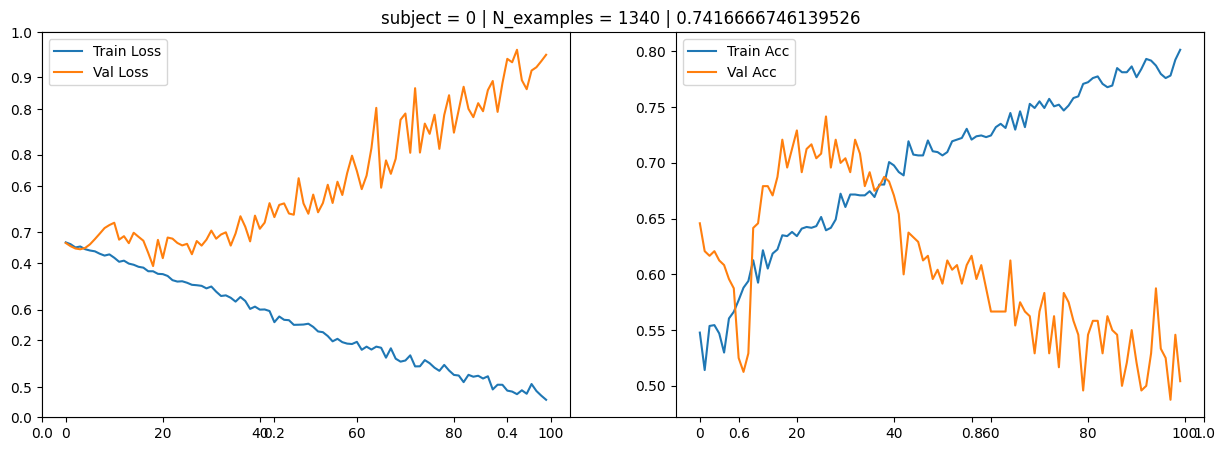

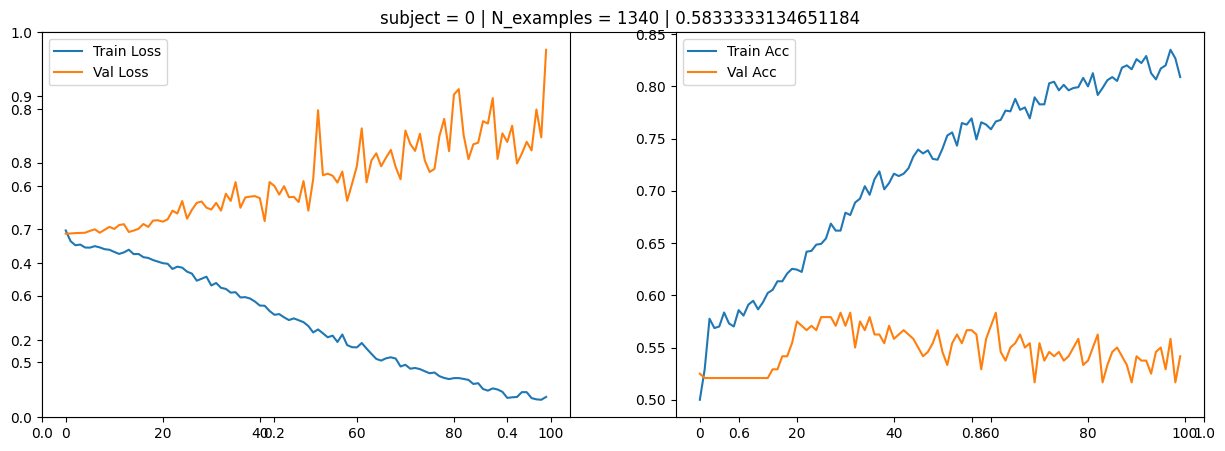

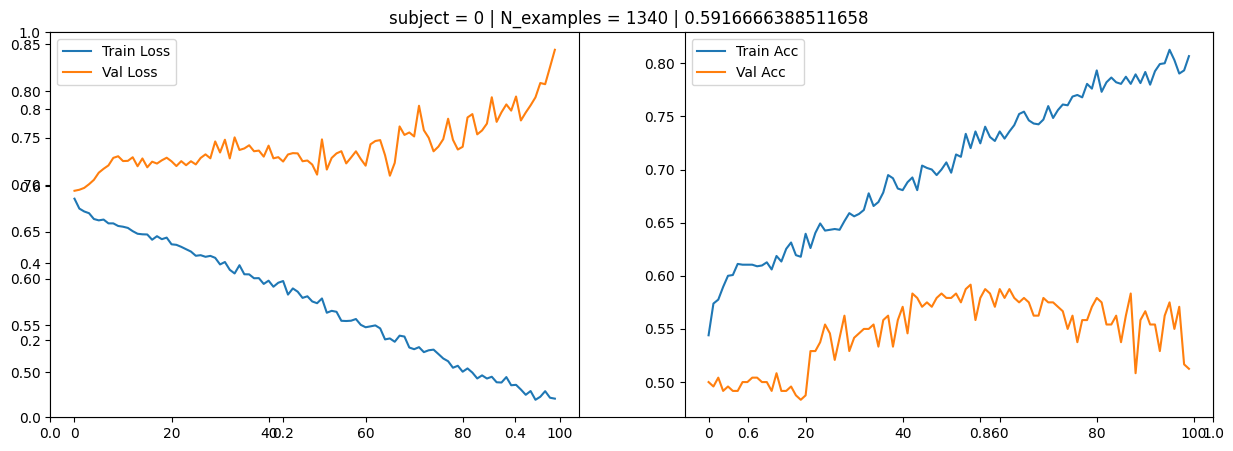

In [3]:
#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=3, test_size=0.15, random_state=0)

                    

acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]


best_model = None
best_acc = 0
best_fold_idx = 0
best_csp = None


for fold_idx, (train_index, valid_index) in tqdm.tqdm(enumerate(crossValidation_KF.split(X,y))):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    print("Training indices: ", train_index)
    print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    #X_train = np.expand_dims(X_train, 3)
    #X_valid = np.expand_dims(X_valid, 3)

    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    model = NetCNN1D(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
            optimizer=keras.optimizers.Adam(learning_rate=2e-4, weight_decay = 1e-5), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    checkpoint_cb = ModelCheckpoint(f'best_model1D_fold_{fold_idx}.tf', save_best_only=True, monitor='val_loss', mode='max', verbose=0, save_format='tf')

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=100, batch_size=32, verbose=0, callbacks=[checkpoint_cb])

    
    val_acc = max(history.history['val_acc'])
    acc.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model
        best_fold_idx = fold_idx
        best_csp = csp 



    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    

if best_model is not None:
    best_model.save('best_model1D.tf', save_format='tf')
    print(f"Best model saved (Fold {best_fold_idx}) with validation accuracy: {best_acc:.4f}")

    with open('csp1D.pkl', 'wb') as f:
        pickle.dump(best_csp, f)


print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")

In [4]:
config.stride = 0.25
config.window_size = 2.0




model = tf.keras.models.load_model('best_model1D.tf')
model.trainable = False

with open('csp1D.pkl', 'rb') as f:
    csp_trained = pickle.load(f)


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)


X_csp_trained = csp_trained.transform(X)
X_csp_trained = X_csp_trained.transpose(0, 2, 1)

y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))

print(model.evaluate(X_csp_trained, y)[1])







old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)

csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')
X = csp.fit_transform(X, y)
X = X.transpose(0, 2, 1)

y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))


sys.stdout.close()
sys.stdout = old_stdout

print(model.evaluate(X, y)[1])

5/5 [==============================] - 0s 13ms/step - loss: 0.7316 - acc: 0.5419
0.5419355034828186
5/5 [==============================] - 0s 8ms/step - loss: 2.6673 - acc: 0.4710
0.47096773982048035


0it [00:00, ?it/s]

Epoch 1/200
17/17 [==============================] - 3s 36ms/step - loss: 0.9401 - acc: 0.4356 - val_loss: 0.7402 - val_acc: 0.5325
Epoch 2/200
17/17 [==============================] - 0s 10ms/step - loss: 0.9059 - acc: 0.4394 - val_loss: 0.7397 - val_acc: 0.5455
Epoch 3/200
17/17 [==============================] - 0s 9ms/step - loss: 0.8740 - acc: 0.4659 - val_loss: 0.7319 - val_acc: 0.5584
Epoch 4/200
17/17 [==============================] - 0s 9ms/step - loss: 0.8432 - acc: 0.4697 - val_loss: 0.7212 - val_acc: 0.5455
Epoch 5/200
17/17 [==============================] - 0s 9ms/step - loss: 0.8302 - acc: 0.4811 - val_loss: 0.7129 - val_acc: 0.5455
Epoch 6/200
17/17 [==============================] - 0s 8ms/step - loss: 0.8189 - acc: 0.4583 - val_loss: 0.7177 - val_acc: 0.5455
Epoch 7/200
17/17 [==============================] - 0s 9ms/step - loss: 0.7927 - acc: 0.4848 - val_loss: 0.7045 - val_acc: 0.5844
Epoch 8/200
17/17 [==============================] - 0s 10ms/step - loss: 0.7787 

1it [00:32, 32.70s/it]

0.6623376607894897
Epoch 1/200
17/17 [==============================] - 2s 30ms/step - loss: 0.5918 - acc: 0.6742 - val_loss: 0.5908 - val_acc: 0.6883
Epoch 2/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5729 - acc: 0.6932 - val_loss: 0.6036 - val_acc: 0.6494
Epoch 3/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5628 - acc: 0.7311 - val_loss: 0.6109 - val_acc: 0.6364
Epoch 4/200
17/17 [==============================] - 0s 8ms/step - loss: 0.5584 - acc: 0.7008 - val_loss: 0.6178 - val_acc: 0.6494
Epoch 5/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5686 - acc: 0.6705 - val_loss: 0.6237 - val_acc: 0.6494
Epoch 6/200
17/17 [==============================] - 0s 8ms/step - loss: 0.5532 - acc: 0.7386 - val_loss: 0.6226 - val_acc: 0.6494
Epoch 7/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5613 - acc: 0.7083 - val_loss: 0.6238 - val_acc: 0.6494
Epoch 8/200
17/17 [==============================] - 0s 8ms/ste

2it [01:03, 31.75s/it]

...

Epoch 1/200
17/17 [==============================] - 2s 29ms/step - loss: 0.4194 - acc: 0.8485 - val_loss: 0.3418 - val_acc: 0.8831
Epoch 2/200
17/17 [==============================] - 0s 9ms/step - loss: 0.4095 - acc: 0.8561 - val_loss: 0.3602 - val_acc: 0.8961
Epoch 3/200
17/17 [==============================] - 0s 9ms/step - loss: 0.3959 - acc: 0.8295 - val_loss: 0.3502 - val_acc: 0.8831
Epoch 4/200
17/17 [==============================] - 0s 10ms/step - loss: 0.4321 - acc: 0.7917 - val_loss: 0.3642 - val_acc: 0.8831
Epoch 5/200
17/17 [==============================] - 0s 10ms/step - loss: 0.3836 - acc: 0.8144 - val_loss: 0.3544 - val_acc: 0.8571
Epoch 6/200
17/17 [==============================] - 0s 9ms/step - loss: 0.3949 - acc: 0.8485 - val_loss: 0.3636 - val_acc: 0.8571
Epoch 7/200
17/17 [==============================] - 0s 10ms/step - loss: 0.4091 - acc: 0.8333 - val_loss: 0.3614 - val_acc: 0.8701
Epoch 8/200
17/17 [==============================] - 0s 12ms/step - loss: 0.429

4it [02:06, 31.33s/it]

0.8961039185523987
Epoch 1/200
17/17 [==============================] - 2s 32ms/step - loss: 0.3575 - acc: 0.8750 - val_loss: 0.3170 - val_acc: 0.8961
Epoch 2/200
17/17 [==============================] - 0s 8ms/step - loss: 0.3610 - acc: 0.8447 - val_loss: 0.3004 - val_acc: 0.9221
Epoch 3/200
17/17 [==============================] - 0s 8ms/step - loss: 0.3878 - acc: 0.8485 - val_loss: 0.3095 - val_acc: 0.9091
Epoch 4/200
17/17 [==============================] - 0s 9ms/step - loss: 0.3852 - acc: 0.8258 - val_loss: 0.3039 - val_acc: 0.9221
Epoch 5/200
17/17 [==============================] - 0s 8ms/step - loss: 0.3427 - acc: 0.8902 - val_loss: 0.2909 - val_acc: 0.9091
Epoch 6/200
17/17 [==============================] - 0s 8ms/step - loss: 0.3717 - acc: 0.8333 - val_loss: 0.3120 - val_acc: 0.8961
Epoch 7/200
17/17 [==============================] - 0s 9ms/step - loss: 0.3729 - acc: 0.8295 - val_loss: 0.2918 - val_acc: 0.9091
Epoch 8/200
17/17 [==============================] - 0s 8ms/ste

5it [02:41, 32.23s/it]

0.9220778942108154



80.78% +- 11.0


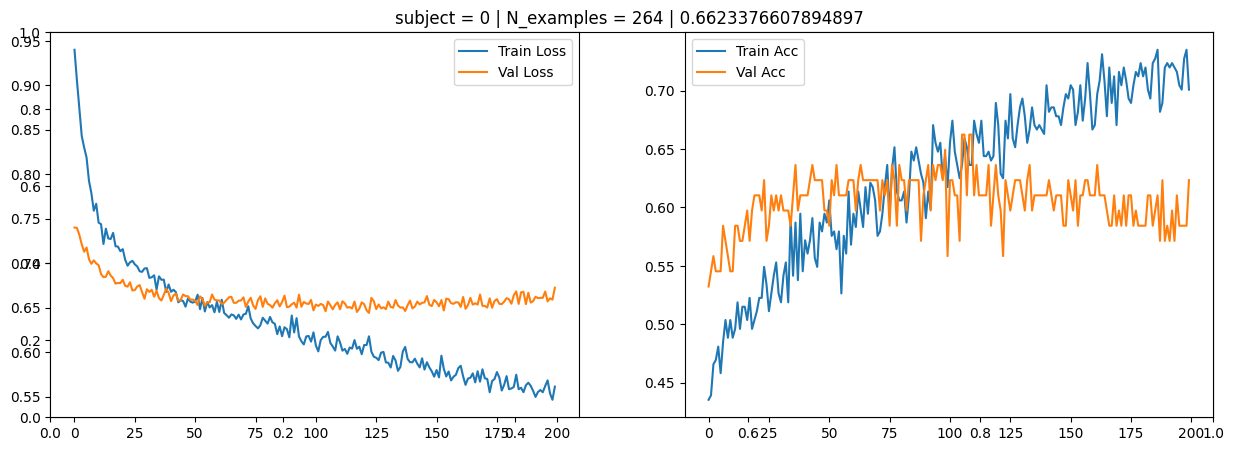

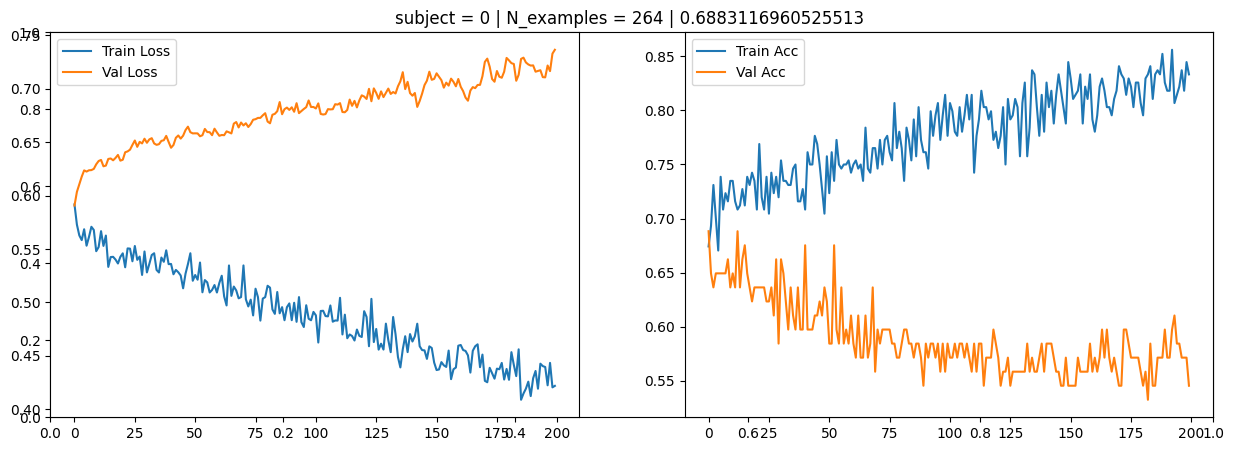

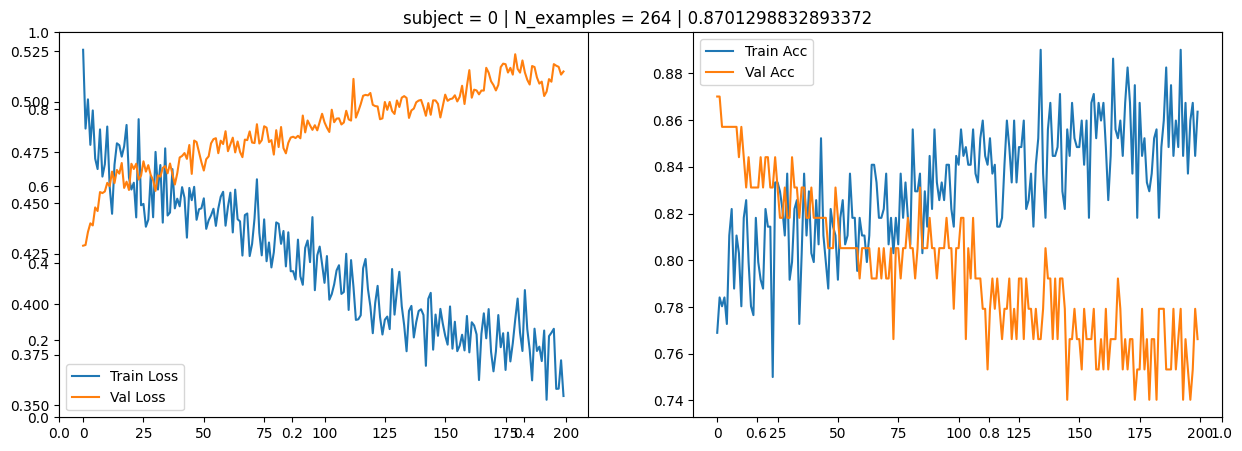

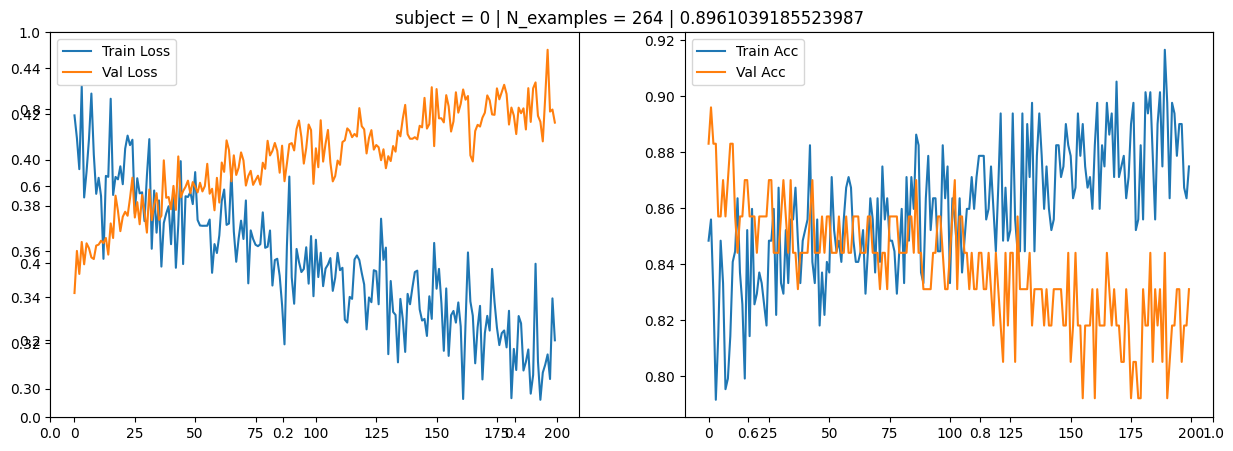

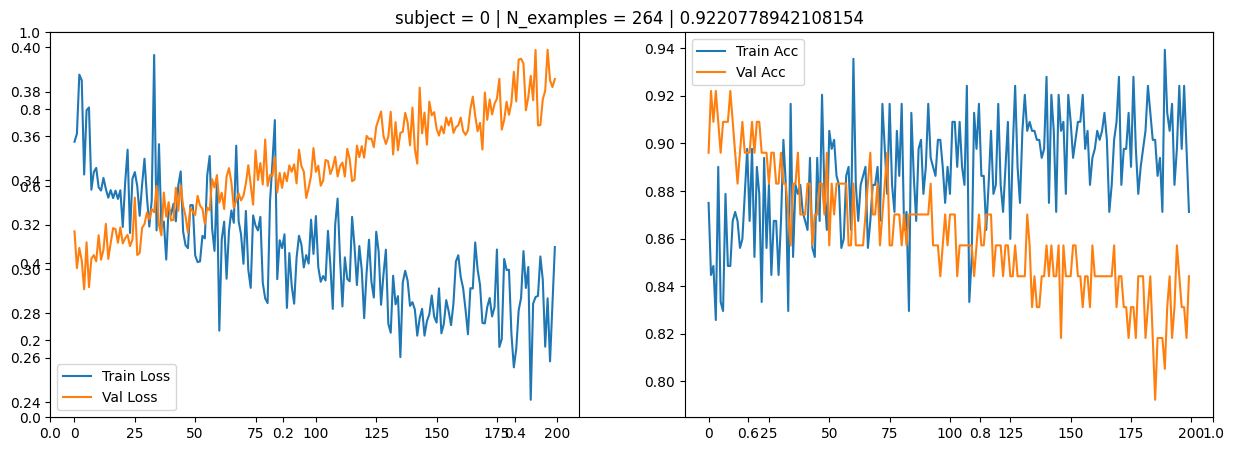

In [5]:
config.stride = 0.1
config.window_size = 2.0


model = tf.keras.models.load_model('best_model1D.tf')
#model.trainable = False 

with open('csp1D.pkl', 'rb') as f:
    csp_trained = pickle.load(f)

for layer in model.layers:
    layer.trainable = False

    if layer.name == 'fc':
        layer.trainable = True


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')










#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in tqdm.tqdm(crossValidation_KF.split(X,y)):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    #print("Training indices: ", train_index)
    #print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    #csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp_trained.transform(X_train)
    #X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp_trained.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    #X_train = np.expand_dims(X_train, 3)
    #X_valid = np.expand_dims(X_valid, 3)

    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    #model = NetCNN2D_CSP(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.01),
            optimizer=keras.optimizers.Adam(learning_rate=5e-4, weight_decay = 5e-7), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=200, batch_size=16, verbose=1)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    print(acc[-1])
    

print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")




0it [00:00, ?it/s]

Epoch 1/200
17/17 [==============================] - 3s 39ms/step - loss: 0.9020 - acc: 0.5000 - val_loss: 1.5832 - val_acc: 0.4545
Epoch 2/200
17/17 [==============================] - 0s 10ms/step - loss: 0.8993 - acc: 0.4697 - val_loss: 1.1754 - val_acc: 0.4805
Epoch 3/200
17/17 [==============================] - 0s 9ms/step - loss: 0.8446 - acc: 0.4811 - val_loss: 0.8867 - val_acc: 0.4805
Epoch 4/200
17/17 [==============================] - 0s 9ms/step - loss: 0.7882 - acc: 0.4962 - val_loss: 0.8776 - val_acc: 0.4805
Epoch 5/200
17/17 [==============================] - 0s 9ms/step - loss: 0.7630 - acc: 0.5341 - val_loss: 0.8150 - val_acc: 0.4805
Epoch 6/200
17/17 [==============================] - 0s 9ms/step - loss: 0.7430 - acc: 0.5227 - val_loss: 0.7854 - val_acc: 0.4545
Epoch 7/200
17/17 [==============================] - 0s 9ms/step - loss: 0.7287 - acc: 0.5303 - val_loss: 0.7461 - val_acc: 0.5065
Epoch 8/200
17/17 [==============================] - 0s 9ms/step - loss: 0.7066 -

1it [00:34, 34.18s/it]

Epoch 1/200
17/17 [==============================] - 2s 37ms/step - loss: 0.6436 - acc: 0.6439 - val_loss: 0.6469 - val_acc: 0.6234
Epoch 2/200
17/17 [==============================] - 0s 9ms/step - loss: 0.6450 - acc: 0.6061 - val_loss: 0.6474 - val_acc: 0.6753
Epoch 3/200
17/17 [==============================] - 0s 10ms/step - loss: 0.6383 - acc: 0.5947 - val_loss: 0.6547 - val_acc: 0.6494
Epoch 4/200
17/17 [==============================] - 0s 10ms/step - loss: 0.6216 - acc: 0.6364 - val_loss: 0.6491 - val_acc: 0.6494
Epoch 5/200
17/17 [==============================] - 0s 10ms/step - loss: 0.6236 - acc: 0.6364 - val_loss: 0.6494 - val_acc: 0.6494
Epoch 6/200
17/17 [==============================] - 0s 9ms/step - loss: 0.6295 - acc: 0.6212 - val_loss: 0.6565 - val_acc: 0.6364
Epoch 7/200
17/17 [==============================] - 0s 10ms/step - loss: 0.6419 - acc: 0.6250 - val_loss: 0.6535 - val_acc: 0.6494
Epoch 8/200
17/17 [==============================] - 0s 10ms/step - loss: 0.62

2it [01:07, 33.54s/it]

...


Epoch 1/200
17/17 [==============================] - 2s 30ms/step - loss: 0.6314 - acc: 0.6515 - val_loss: 0.8427 - val_acc: 0.5065
Epoch 2/200
17/17 [==============================] - 0s 9ms/step - loss: 0.6151 - acc: 0.6439 - val_loss: 0.8301 - val_acc: 0.5065
Epoch 3/200
17/17 [==============================] - 0s 9ms/step - loss: 0.6076 - acc: 0.6288 - val_loss: 0.8115 - val_acc: 0.5325
Epoch 4/200
17/17 [==============================] - 0s 9ms/step - loss: 0.6243 - acc: 0.6477 - val_loss: 0.7992 - val_acc: 0.5325
Epoch 5/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5817 - acc: 0.6780 - val_loss: 0.7853 - val_acc: 0.5195
Epoch 6/200
17/17 [==============================] - 0s 10ms/step - loss: 0.5841 - acc: 0.6780 - val_loss: 0.7894 - val_acc: 0.5584
Epoch 7/200
17/17 [==============================] - 0s 10ms/step - loss: 0.5774 - acc: 0.6742 - val_loss: 0.7804 - val_acc: 0.5584
Epoch 8/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5690

4it [02:13, 33.31s/it]

Epoch 1/200
17/17 [==============================] - 2s 45ms/step - loss: 0.6996 - acc: 0.5833 - val_loss: 0.6690 - val_acc: 0.6494
Epoch 2/200
17/17 [==============================] - 0s 10ms/step - loss: 0.6317 - acc: 0.6553 - val_loss: 0.6264 - val_acc: 0.6623
Epoch 3/200
17/17 [==============================] - 0s 10ms/step - loss: 0.6333 - acc: 0.6174 - val_loss: 0.6139 - val_acc: 0.6623
Epoch 4/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5913 - acc: 0.6780 - val_loss: 0.6277 - val_acc: 0.6623
Epoch 5/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5863 - acc: 0.6932 - val_loss: 0.6415 - val_acc: 0.6364
Epoch 6/200
17/17 [==============================] - 0s 10ms/step - loss: 0.5794 - acc: 0.6894 - val_loss: 0.6241 - val_acc: 0.6753
Epoch 7/200
17/17 [==============================] - 0s 9ms/step - loss: 0.5810 - acc: 0.7045 - val_loss: 0.6385 - val_acc: 0.6364
Epoch 8/200
17/17 [==============================] - 0s 8ms/step - loss: 0.5447

5it [02:49, 33.82s/it]





63.12% +- 4.0


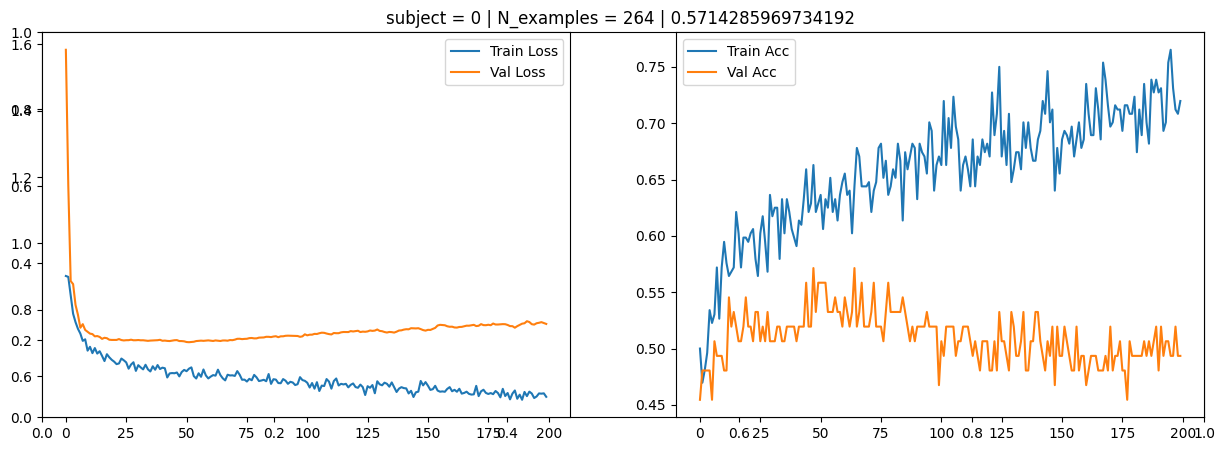

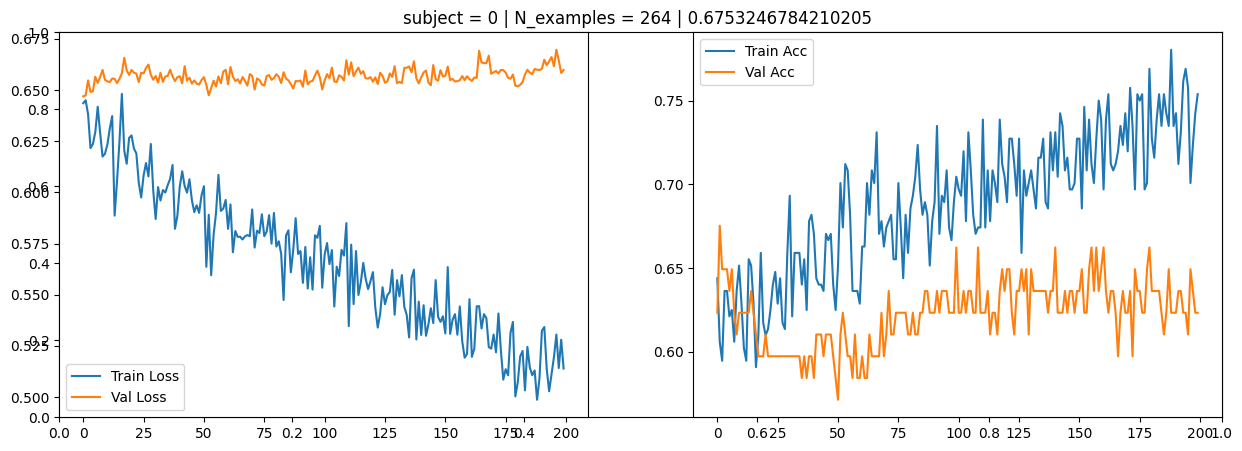

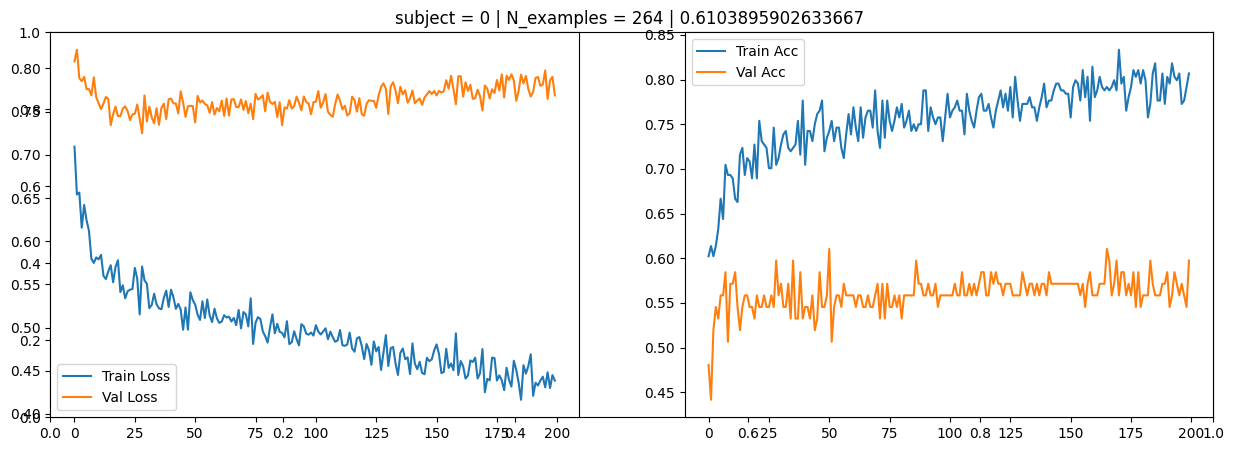

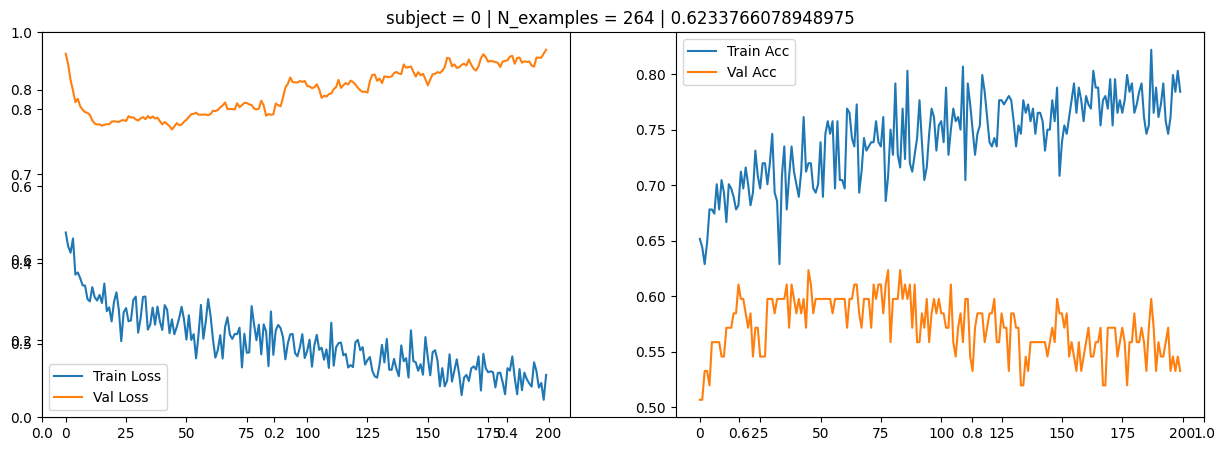

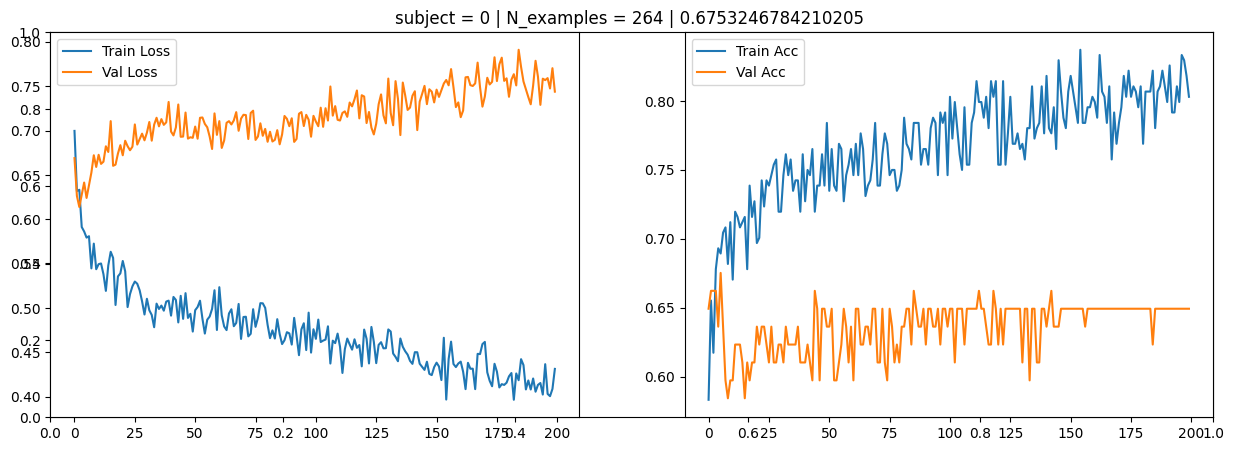

In [6]:
config.stride = 0.1
config.window_size = 2.0


model = tf.keras.models.load_model('best_model1D.tf')
#model.trainable = False 

with open('csp1D.pkl', 'rb') as f:
    csp_trained = pickle.load(f)

for layer in model.layers:
    layer.trainable = False

    if layer.name == 'fc':
        layer.trainable = True


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')










#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in tqdm.tqdm(crossValidation_KF.split(X,y)):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    #print("Training indices: ", train_index)
    #print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    #X_train = csp.transform(X_train)
    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    #X_train = np.expand_dims(X_train, 3)
    #X_valid = np.expand_dims(X_valid, 3)

    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    #model = NetCNN2D_CSP(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.01),
            optimizer=keras.optimizers.Adam(learning_rate=5e-4, weight_decay = 5e-7), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=200, batch_size=16, verbose=1)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    print(acc[-1])
    

print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")


